# CCPS 844 Data Mining Project
## Classification & Regression Analysis

**Author:** Amir Ali Eslami  
**Student Number:** 501200510  
**Course:** CCPS 844  
**Date:** July 2026


## Table of Contents

1. [**Step 1 – Outline / Table of Contents**](#step-1)
2. [**Step 2 – Dataset Selection**](#step-2)
3. [**Step 3 – Problem Statement**](#step-3)
4. [**Step 4 – Independent & Dependent Variables**](#step-4)
5. [**Step 5 – Algorithms Used**](#step-5)
6. [**Step 6 – Data Type Checking & Conversion**](#step-6)
7. [**Step 7 – Data Visualization**](#step-7)
8. [**Step 8 – Clustering (Exploratory Analysis)**](#step-8)
9. [**Step 9 – Feature Selection**](#step-9)
10. [**Step 10 – Scaling, Dimensionality Reduction & Model Evaluation**](#step-10)
11. [**Step 11 – Train/Test Split & Algorithm Comparison**](#step-11)
12. [**Step 12 – Conclusions**](#step-12)

---


<a id='step-1'></a>
## **Step 1 – Outline / Table of Contents**

This notebook follows the 12 mandatory steps required for the CCPS 844 Data Mining project. Each section is clearly labelled with a bold title and includes markdown explanations describing:

- **What** we are doing at each step
- **Why** we selected that step (reasoning)
- **What** we learned from the previous step
- **What** we expect from the next step

Use the hyperlinks in the Table of Contents above to navigate directly to any section.


<a id='step-2'></a>
## **Step 2 – Dataset Selection**

We selected **two publicly available datasets** from the [UCI Machine Learning Repository](http://archive.ics.uci.edu/ml/) (one of the recommended sources in the project brief):

| Task | Dataset | Source | Records |
|------|---------|--------|---------|
| **Classification** | Heart Disease (Cleveland) | UCI ML Repository | 303 patients |
| **Regression** | Auto MPG (Fuel Efficiency) | UCI ML Repository | 392 vehicles |

**Reason for selection:** Both datasets are well-studied, contain a mix of numerical and categorical features, and address real-world problems in healthcare and automotive engineering. They are small enough to explore thoroughly yet rich enough to demonstrate clustering, feature selection, and dimensionality reduction.

**From previous step:** We established the project structure.  
**Expectation for next step:** We will define the specific prediction problems for each dataset.


<a id='step-3'></a>
## **Step 3 – Problem Statement**

### Classification Problem
**Can we predict whether a patient has heart disease based on clinical measurements?**

Heart disease is a leading cause of death worldwide. Early detection through predictive modelling can help clinicians identify at-risk patients. We use the Cleveland Heart Disease dataset to build a **binary classifier** that predicts whether a patient has heart disease (1) or not (0), based on features such as age, cholesterol, blood pressure, and ECG results.

### Regression Problem
**Can we predict a vehicle's fuel efficiency (miles per gallon) from its physical and engine characteristics?**

Fuel efficiency is critical for environmental sustainability and consumer cost savings. We use the Auto MPG dataset to build a **regression model** that predicts `mpg` (miles per gallon) from features such as engine displacement, horsepower, weight, and model year.

**From previous step:** We chose our datasets.  
**Expectation for next step:** We will list all independent and dependent variables.


<a id='step-4'></a>
## **Step 4 – Independent & Dependent Variables**

### Classification (Heart Disease)

| Role | Variable | Description |
|------|----------|-------------|
| **Dependent (Target)** | `target` | Heart disease presence (0 = no disease, 1 = disease) |
| **Independent** | `age` | Age in years |
| **Independent** | `sex` | Sex (1 = male, 0 = female) |
| **Independent** | `cp` | Chest pain type (1–4) |
| **Independent** | `trestbps` | Resting blood pressure (mm Hg) |
| **Independent** | `chol` | Serum cholesterol (mg/dl) |
| **Independent** | `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) |
| **Independent** | `restecg` | Resting ECG results (0–2) |
| **Independent** | `thalach` | Maximum heart rate achieved |
| **Independent** | `exang` | Exercise induced angina (1 = yes) |
| **Independent** | `oldpeak` | ST depression induced by exercise |
| **Independent** | `slope` | Slope of peak exercise ST segment |
| **Independent** | `ca` | Number of major vessels (0–3) |
| **Independent** | `thal` | Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect) |

### Regression (Auto MPG)

| Role | Variable | Description |
|------|----------|-------------|
| **Dependent (Target)** | `mpg` | Miles per gallon (fuel efficiency) |
| **Independent** | `cylinders` | Number of engine cylinders |
| **Independent** | `displacement` | Engine displacement (cubic inches) |
| **Independent** | `horsepower` | Engine horsepower |
| **Independent** | `weight` | Vehicle weight (lbs) |
| **Independent** | `acceleration` | Time to accelerate 0–60 mph (seconds) |
| **Independent** | `model_year` | Model year (70–82) |
| **Independent** | `origin` | Origin (1 = USA, 2 = Europe, 3 = Japan) |

**From previous step:** We defined our problems.  
**Expectation for next step:** We will list all algorithms to be applied.


<a id='step-5'></a>
## **Step 5 – Algorithms Used**

### Classification Algorithms
1. **Logistic Regression** – Linear baseline for binary classification
2. **K-Nearest Neighbors (KNN)** – Instance-based learning
3. **Decision Tree** – Non-linear, interpretable tree model
4. **Random Forest** – Ensemble of decision trees
5. **Support Vector Machine (SVM)** – Maximum-margin classifier
6. **Naive Bayes (Gaussian)** – Probabilistic classifier

### Regression Algorithms
1. **Linear Regression** – Simple linear baseline
2. **Ridge Regression** – L2-regularised linear regression
3. **Lasso Regression** – L1-regularised linear regression (feature shrinkage)
4. **K-Nearest Neighbors Regressor** – Instance-based regression
5. **Decision Tree Regressor** – Non-linear tree-based regression
6. **Random Forest Regressor** – Ensemble tree regression

### Clustering Algorithms (Step 8)
1. **K-Means Clustering**
2. **Agglomerative (Hierarchical) Clustering**

### Feature Selection Methods (Step 9)
1. **Correlation-based filtering**
2. **Mutual Information**
3. **Recursive Feature Elimination (RFE)**

### Dimensionality Reduction (Step 10)
1. **Principal Component Analysis (PCA)**

**From previous step:** We identified our variables.  
**Expectation for next step:** We will load the data and verify column types.


<a id='step-6'></a>
## **Step 6 – Data Type Checking & Conversion**

After reading each dataset, we inspect column data types to ensure numeric columns are stored as numeric types and categorical columns are appropriately encoded. Columns stored as `object` that should be numeric will be converted. Missing values will be identified and handled.

**Reason:** Machine learning algorithms require properly typed features. Regression targets must be numeric; classification targets must be categorical (or encoded numerically).

**From previous step:** We listed our algorithms.  
**Expectation for next step:** We will visualise the data to understand distributions and relationships.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, RFE
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_squared_error, mean_absolute_error, r2_score, silhouette_score)

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('All libraries imported successfully.')


All libraries imported successfully.


In [2]:
# --- Load Heart Disease (Classification) Dataset ---
heart_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
              'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df_class = pd.read_csv('data/heart_disease.csv', header=None, names=heart_cols, na_values='?')

print('=== Heart Disease Dataset ===')
print(f'Shape: {df_class.shape}')
print(f'\nData Types:\n{df_class.dtypes}')
print(f'\nMissing values:\n{df_class.isnull().sum()}')
df_class.head()


=== Heart Disease Dataset ===
Shape: (303, 14)

Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# --- Load Auto MPG (Regression) Dataset ---
mpg_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
            'acceleration', 'model_year', 'origin', 'car_name']
df_reg = pd.read_csv('data/auto_mpg.csv', sep=r'\s+', names=mpg_cols, na_values='?')

print('=== Auto MPG Dataset ===')
print(f'Shape: {df_reg.shape}')
print(f'\nData Types:\n{df_reg.dtypes}')
print(f'\nMissing values:\n{df_reg.isnull().sum()}')
df_reg.head()


=== Auto MPG Dataset ===
Shape: (398, 9)

Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name            str
dtype: object

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [4]:
# --- Data Type Conversion: Heart Disease ---
# Convert any object columns to numeric
for col in df_class.columns:
    if df_class[col].dtype == 'object':
        df_class[col] = pd.to_numeric(df_class[col], errors='coerce')
        print(f'Converted {col} from object to numeric')

# Handle missing values
df_class.dropna(inplace=True)

# Convert target to binary: 0 = no disease, 1 = disease (original 1-4 -> 1, 0 stays 0)
df_class['target'] = (df_class['target'] > 0).astype(int)

print(f'\nAfter cleaning - Shape: {df_class.shape}')
print(f'Data Types:\n{df_class.dtypes}')
print(f'\nTarget distribution:\n{df_class["target"].value_counts()}')



After cleaning - Shape: (297, 14)
Data Types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Target distribution:
target
0    160
1    137
Name: count, dtype: int64


In [5]:
# --- Data Type Conversion: Auto MPG ---
# Drop car_name (not useful for modelling)
df_reg.drop('car_name', axis=1, inplace=True)

# Convert object columns to numeric
for col in df_reg.columns:
    if df_reg[col].dtype == 'object':
        df_reg[col] = pd.to_numeric(df_reg[col], errors='coerce')
        print(f'Converted {col} from object to numeric')

# Handle missing values (horsepower has some missing values marked as '?')
df_reg.dropna(inplace=True)

print(f'\nAfter cleaning - Shape: {df_reg.shape}')
print(f'Data Types:\n{df_reg.dtypes}')
print(f'\nMPG statistics:\n{df_reg["mpg"].describe()}')



After cleaning - Shape: (392, 8)
Data Types:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
dtype: object

MPG statistics:
count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64


<a id='step-7'></a>
## **Step 7 – Data Visualization**

We use **matplotlib**, **seaborn**, and **plotly** to explore data distributions, correlations, and relationships between features and targets. Visual exploration helps identify outliers, skewness, class imbalance, and multicollinearity before modelling.

**Reason:** Understanding data visually guides feature engineering, scaling decisions, and algorithm selection.

**From previous step:** Data is clean and properly typed.  
**Expectation for next step:** We will apply clustering to discover hidden group structures.


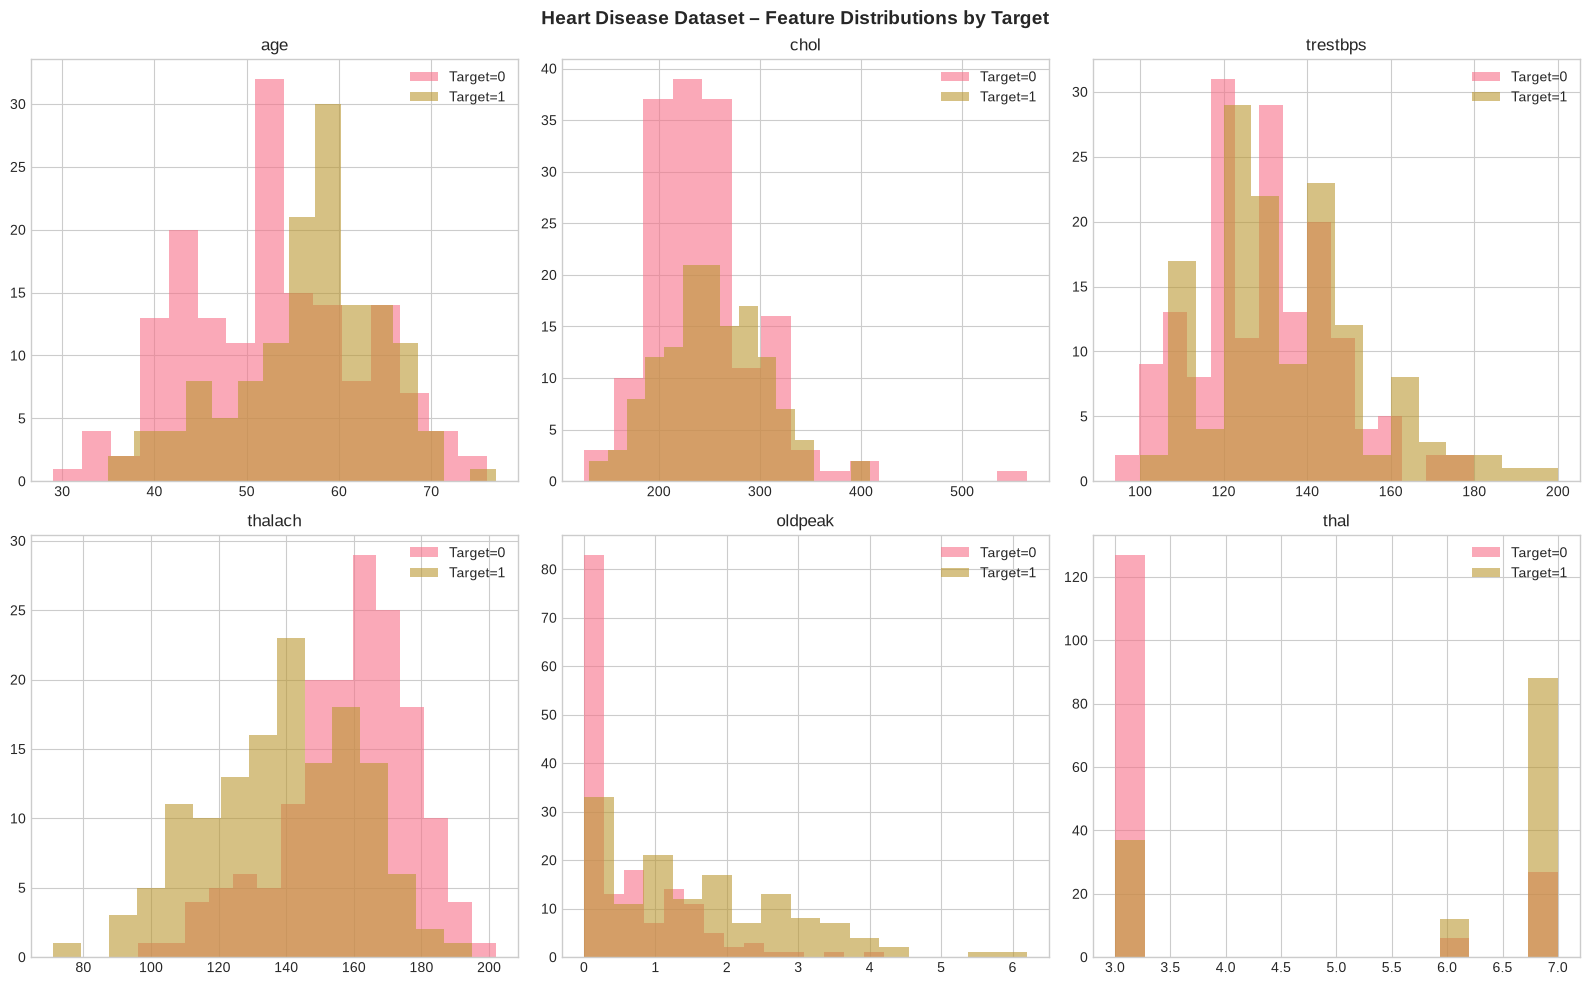

In [6]:
# --- Classification: Distribution plots ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Heart Disease Dataset – Feature Distributions by Target', fontsize=14, fontweight='bold')

features_to_plot = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak', 'thal']
for ax, feat in zip(axes.flatten(), features_to_plot):
    for label in [0, 1]:
        subset = df_class[df_class['target'] == label][feat]
        ax.hist(subset, alpha=0.6, label=f'Target={label}', bins=15)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()


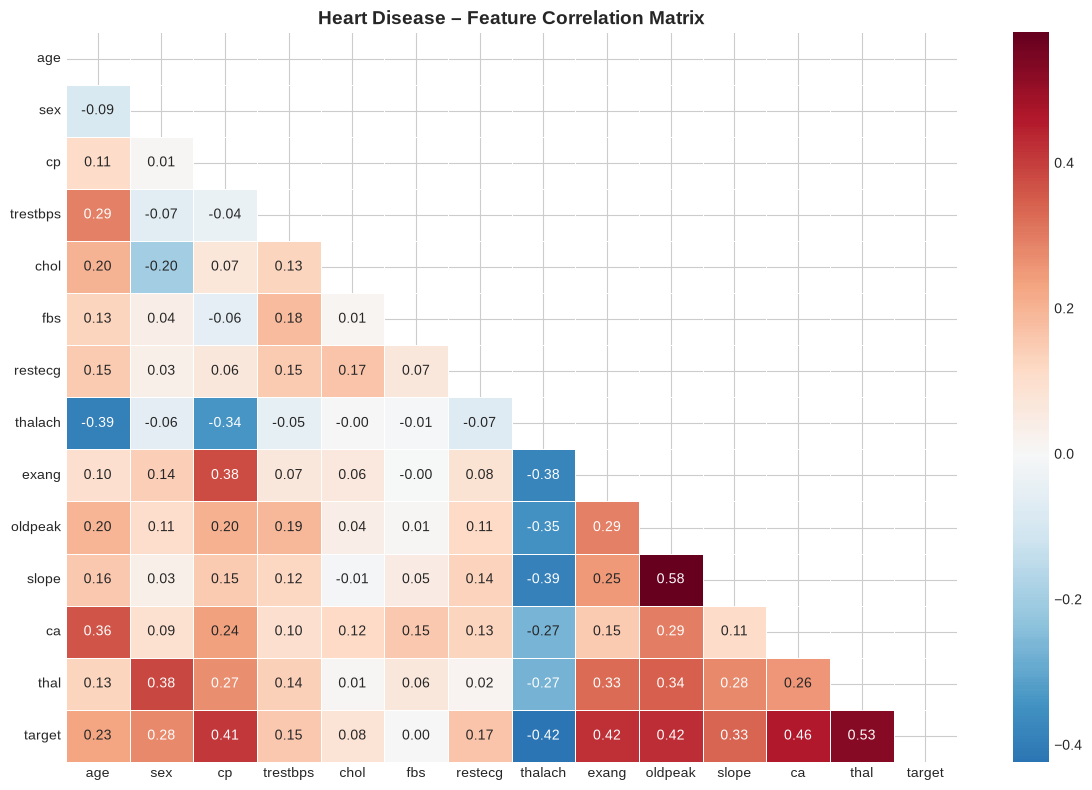

In [7]:
# --- Classification: Correlation heatmap (seaborn) ---
plt.figure(figsize=(12, 8))
corr_class = df_class.corr()
mask = np.triu(np.ones_like(corr_class, dtype=bool))
sns.heatmap(corr_class, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Heart Disease – Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
# --- Classification: Interactive plotly scatter ---
fig = px.scatter(df_class, x='age', y='chol', color='target',
                 title='Age vs Cholesterol coloured by Heart Disease',
                 labels={'target': 'Heart Disease'}, opacity=0.7,
                 color_discrete_map={0: '#2ecc71', 1: '#e74c3c'})
fig.update_layout(width=800, height=500)
fig.show()


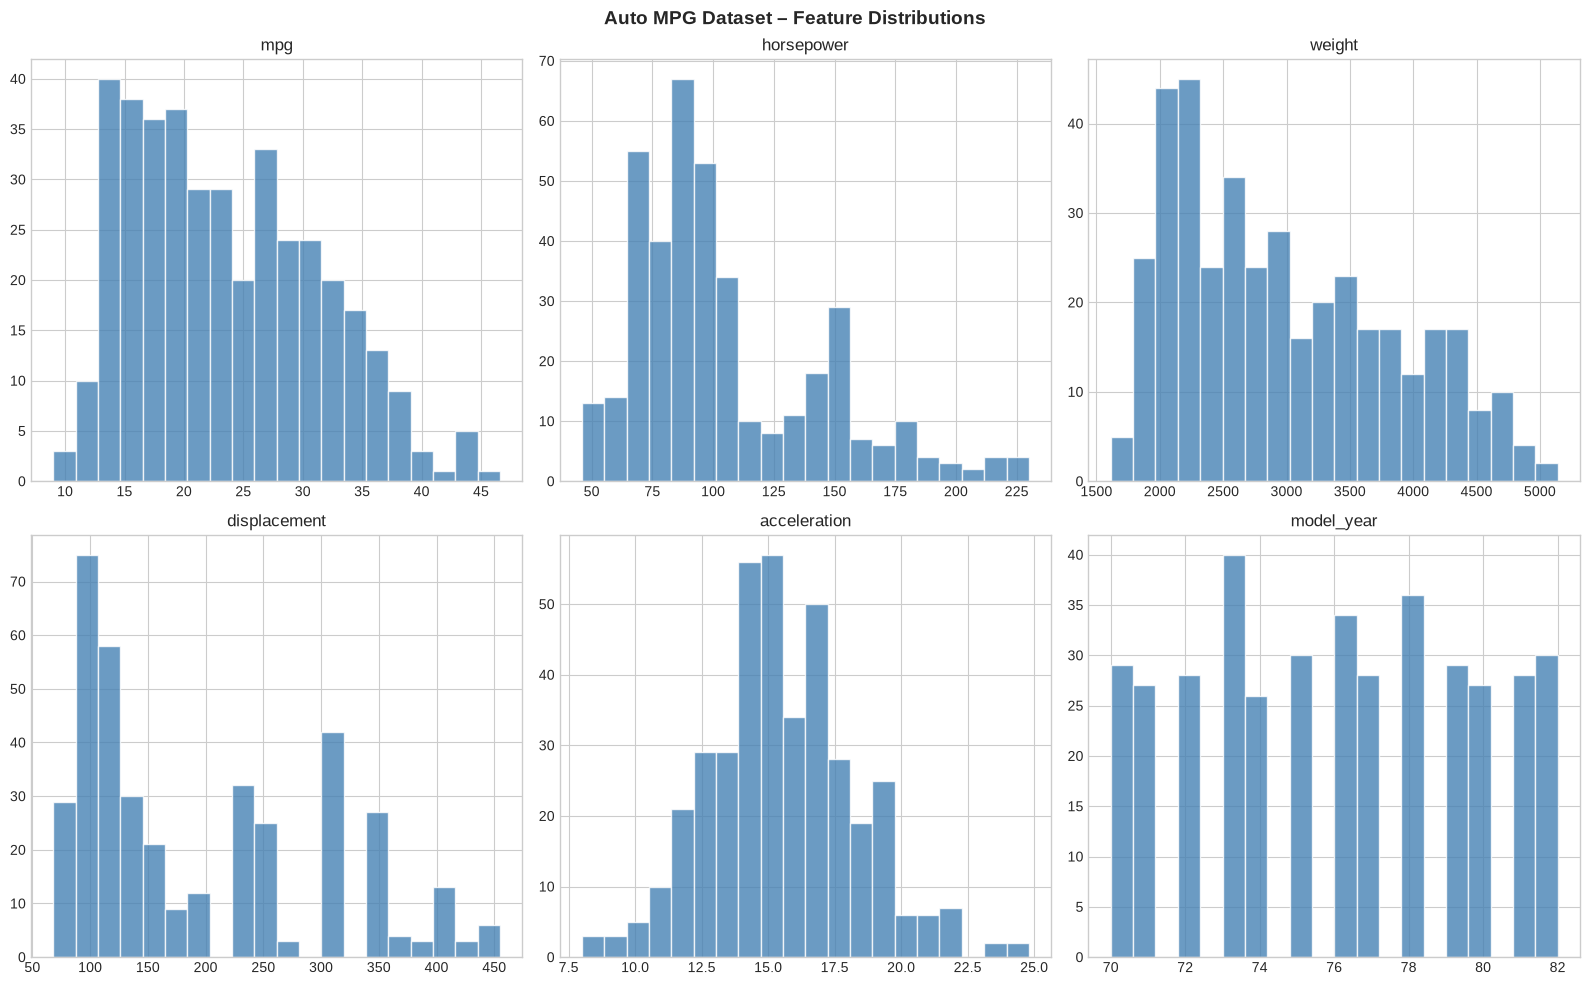

In [9]:
# --- Regression: Distribution plots ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Auto MPG Dataset – Feature Distributions', fontsize=14, fontweight='bold')

reg_features = ['mpg', 'horsepower', 'weight', 'displacement', 'acceleration', 'model_year']
for ax, feat in zip(axes.flatten(), reg_features):
    ax.hist(df_reg[feat], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


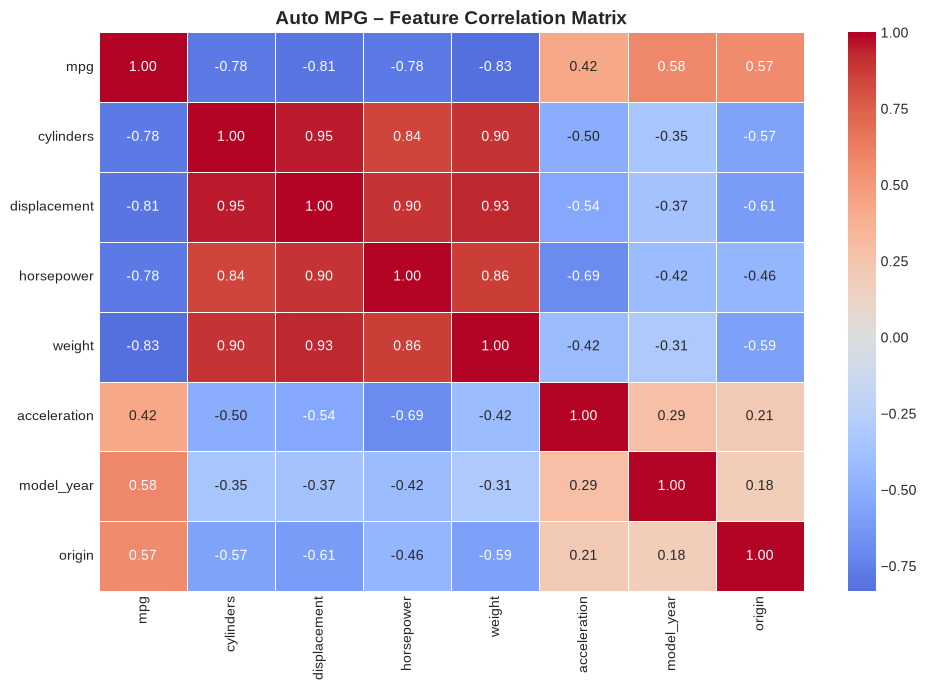

In [10]:
# --- Regression: Correlation heatmap ---
plt.figure(figsize=(10, 7))
corr_reg = df_reg.corr()
sns.heatmap(corr_reg, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Auto MPG – Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
# --- Regression: Interactive plotly 3D scatter ---
fig = px.scatter_3d(df_reg, x='horsepower', y='weight', z='mpg',
                    color='mpg', title='Horsepower vs Weight vs MPG',
                    color_continuous_scale='Viridis', opacity=0.8)
fig.update_layout(width=800, height=600)
fig.show()


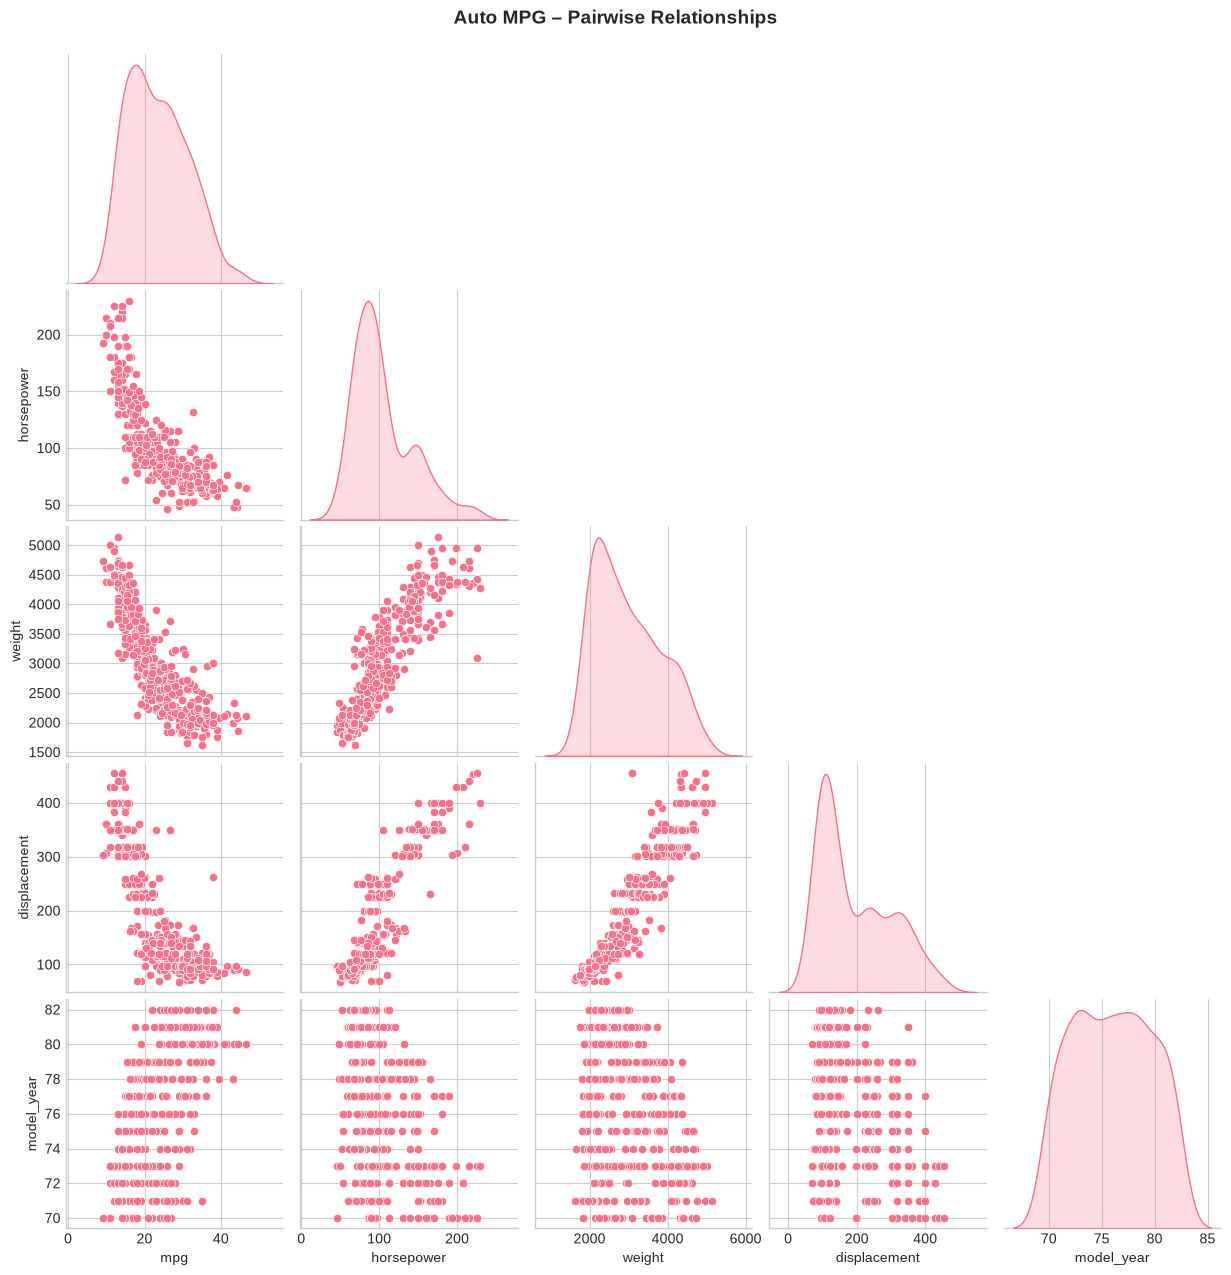

In [12]:
# --- Regression: Pairplot for key features ---
sns.pairplot(df_reg[['mpg', 'horsepower', 'weight', 'displacement', 'model_year']],
             diag_kind='kde', corner=True)
plt.suptitle('Auto MPG – Pairwise Relationships', y=1.02, fontsize=14, fontweight='bold')
plt.show()


<a id='step-8'></a>
## **Step 8 – Clustering (Exploratory Analysis)**

We apply **K-Means** and **Agglomerative (Hierarchical) Clustering** to both datasets to discover natural groupings. Clustering is unsupervised and helps us understand whether patients/vehicles form distinct segments, which can inform feature engineering and model design.

**Reason:** Clustering reveals hidden structure in the data that supervised models may not capture directly.

**From previous step:** Visualisations showed feature distributions and correlations.  
**Expectation for next step:** We will select the most informative features for modelling.


K-Means Silhouette Score (Heart Disease): 0.1298
Hierarchical Silhouette Score (Heart Disease): 0.1518


target,0,1,All
kmeans_cluster,,,
0,79,38,117
1,10,91,101
2,71,8,79
All,160,137,297


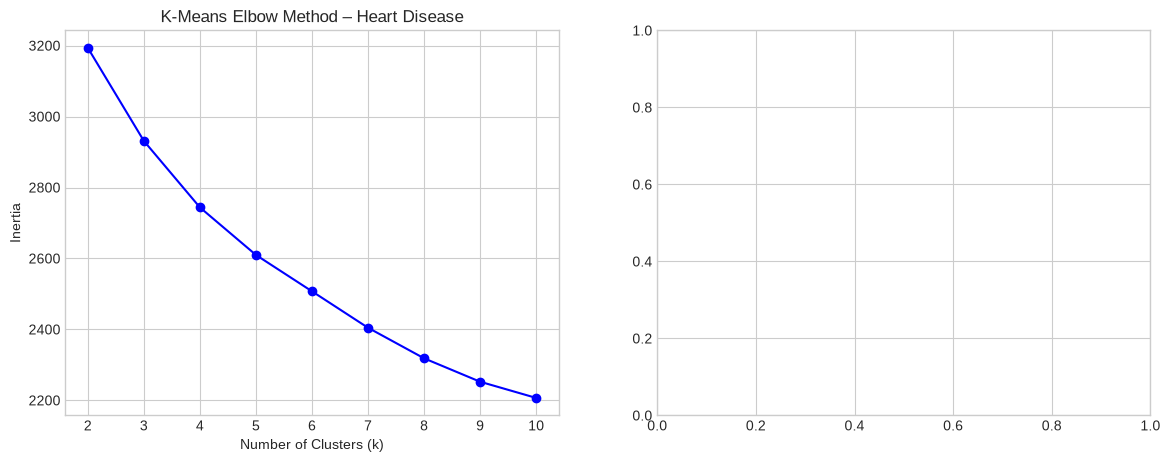

In [13]:
# --- K-Means: Heart Disease ---
X_clust_class = StandardScaler().fit_transform(df_class.drop('target', axis=1))

# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_class)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means Elbow Method – Heart Disease')

# Apply K-Means with k=3
km_class = KMeans(n_clusters=3, random_state=42, n_init=10)
df_class['kmeans_cluster'] = km_class.fit_predict(X_clust_class)
sil_km_class = silhouette_score(X_clust_class, df_class['kmeans_cluster'])
print(f'K-Means Silhouette Score (Heart Disease): {sil_km_class:.4f}')

# Hierarchical clustering
hc_class = AgglomerativeClustering(n_clusters=3)
df_class['hc_cluster'] = hc_class.fit_predict(X_clust_class)
sil_hc_class = silhouette_score(X_clust_class, df_class['hc_cluster'])
print(f'Hierarchical Silhouette Score (Heart Disease): {sil_hc_class:.4f}')

# Visualise clusters vs actual target
pd.crosstab(df_class['kmeans_cluster'], df_class['target'], margins=True)


K-Means Silhouette Score (Auto MPG): 0.3489
Hierarchical Silhouette Score (Auto MPG): 0.3276


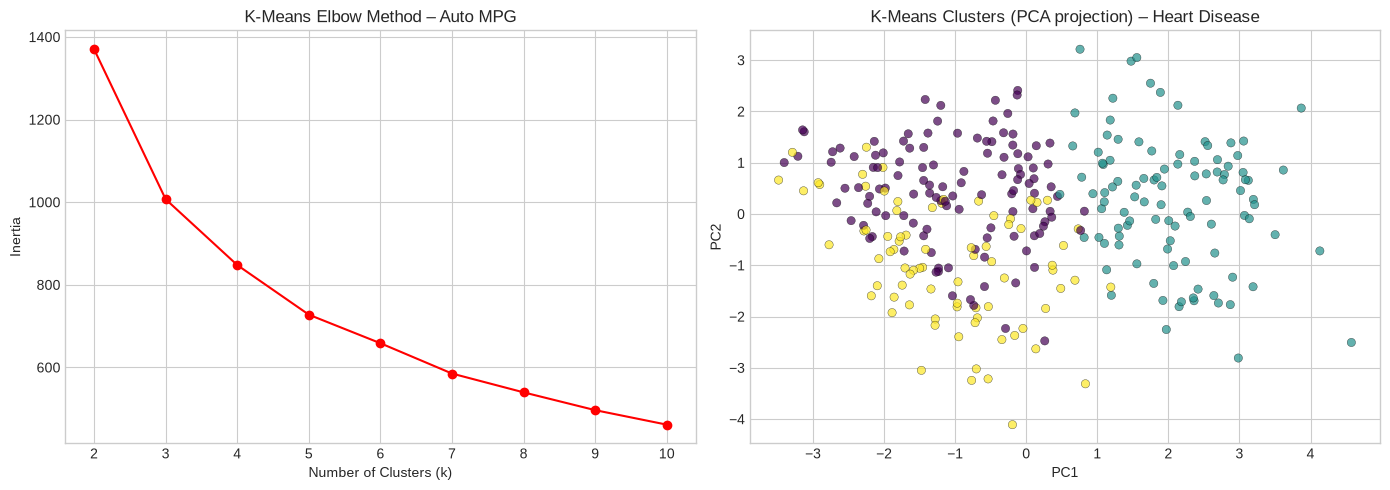

In [14]:
# --- K-Means: Auto MPG ---
X_clust_reg = StandardScaler().fit_transform(df_reg.drop('mpg', axis=1))

inertias_reg = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_reg)
    inertias_reg.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias_reg, 'ro-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means Elbow Method – Auto MPG')

km_reg = KMeans(n_clusters=3, random_state=42, n_init=10)
df_reg['kmeans_cluster'] = km_reg.fit_predict(X_clust_reg)
sil_km_reg = silhouette_score(X_clust_reg, df_reg['kmeans_cluster'])
print(f'K-Means Silhouette Score (Auto MPG): {sil_km_reg:.4f}')

hc_reg = AgglomerativeClustering(n_clusters=3)
df_reg['hc_cluster'] = hc_reg.fit_predict(X_clust_reg)
sil_hc_reg = silhouette_score(X_clust_reg, df_reg['hc_cluster'])
print(f'Hierarchical Silhouette Score (Auto MPG): {sil_hc_reg:.4f}')

# PCA for 2D cluster visualisation
pca_vis = PCA(n_components=2)
X_pca_class = pca_vis.fit_transform(X_clust_class)

axes[1].scatter(X_pca_class[:, 0], X_pca_class[:, 1], c=df_class['kmeans_cluster'],
                cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.3)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('K-Means Clusters (PCA projection) – Heart Disease')
plt.tight_layout()
plt.show()


<a id='step-9'></a>
## **Step 9 – Feature Selection**

We apply Module 9 feature selection techniques to identify the most informative predictors:

1. **Correlation-based filtering** – Remove highly correlated redundant features
2. **Mutual Information** – Measure non-linear dependency between features and target
3. **Recursive Feature Elimination (RFE)** – Iteratively remove least important features using a model

**Reason:** Feature selection reduces overfitting, improves interpretability, and can boost model performance by removing noise.

**From previous step:** Clustering revealed natural groupings in the data.  
**Expectation for next step:** We will scale features, apply PCA, and evaluate models under three scenarios.


In [15]:
# --- Feature Selection: Heart Disease (Classification) ---
X_class_full = df_class.drop(['target', 'kmeans_cluster', 'hc_cluster'], axis=1)
y_class = df_class['target']

# 1. Correlation with target
corr_with_target = X_class_full.corrwith(y_class).abs().sort_values(ascending=False)
print('=== Classification: Correlation with Target ===')
print(corr_with_target)

# 2. Mutual Information
mi_class = mutual_info_classif(X_class_full, y_class, random_state=42)
mi_class_series = pd.Series(mi_class, index=X_class_full.columns).sort_values(ascending=False)
print('\n=== Classification: Mutual Information Scores ===')
print(mi_class_series)

# 3. RFE with Logistic Regression
rfe_class = RFE(LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=8)
rfe_class.fit(X_class_full, y_class)
rfe_class_features = X_class_full.columns[rfe_class.support_].tolist()
print(f'\n=== Classification: RFE Selected Features ===')
print(rfe_class_features)

# Select top features by mutual information (top 8)
selected_class_features = mi_class_series.head(8).index.tolist()
print(f'\nSelected features for modelling: {selected_class_features}')


=== Classification: Correlation with Target ===
thal        0.526640
ca          0.463189
oldpeak     0.424052
thalach     0.423817
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
dtype: float64



=== Classification: Mutual Information Scores ===
thal        0.152849
cp          0.140168
ca          0.129880
chol        0.087596
exang       0.086220
oldpeak     0.085699
thalach     0.085376
sex         0.041562
slope       0.038670
restecg     0.015812
age         0.000000
trestbps    0.000000
fbs         0.000000
dtype: float64



=== Classification: RFE Selected Features ===
['sex', 'cp', 'fbs', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Selected features for modelling: ['thal', 'cp', 'ca', 'chol', 'exang', 'oldpeak', 'thalach', 'sex']


In [16]:
# --- Feature Selection: Auto MPG (Regression) ---
X_reg_full = df_reg.drop(['mpg', 'kmeans_cluster', 'hc_cluster'], axis=1)
y_reg = df_reg['mpg']

# 1. Correlation with target
corr_reg_target = X_reg_full.corrwith(y_reg).abs().sort_values(ascending=False)
print('=== Regression: Correlation with Target ===')
print(corr_reg_target)

# 2. Mutual Information
mi_reg = mutual_info_regression(X_reg_full, y_reg, random_state=42)
mi_reg_series = pd.Series(mi_reg, index=X_reg_full.columns).sort_values(ascending=False)
print('\n=== Regression: Mutual Information Scores ===')
print(mi_reg_series)

# 3. RFE with Linear Regression
rfe_reg = RFE(LinearRegression(), n_features_to_select=5)
rfe_reg.fit(X_reg_full, y_reg)
rfe_reg_features = X_reg_full.columns[rfe_reg.support_].tolist()
print(f'\n=== Regression: RFE Selected Features ===')
print(rfe_reg_features)

# Select top features by mutual information (top 5)
selected_reg_features = mi_reg_series.head(5).index.tolist()
print(f'\nSelected features for modelling: {selected_reg_features}')


=== Regression: Correlation with Target ===
weight          0.832244
displacement    0.805127
horsepower      0.778427
cylinders       0.777618
model_year      0.580541
origin          0.565209
acceleration    0.423329
dtype: float64

=== Regression: Mutual Information Scores ===
displacement    0.791624
weight          0.774641
horsepower      0.724266
cylinders       0.655657
model_year      0.355546
origin          0.260072
acceleration    0.194187
dtype: float64

=== Regression: RFE Selected Features ===
['cylinders', 'horsepower', 'acceleration', 'model_year', 'origin']

Selected features for modelling: ['displacement', 'weight', 'horsepower', 'cylinders', 'model_year']


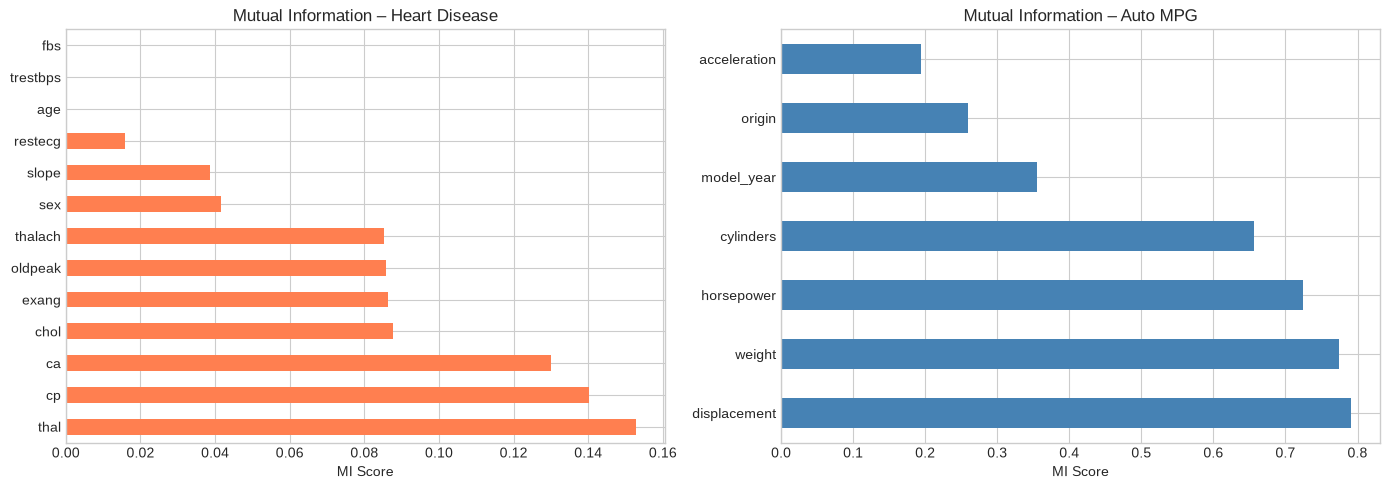

In [17]:
# Visualise feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mi_class_series.plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Mutual Information – Heart Disease')
axes[0].set_xlabel('MI Score')

mi_reg_series.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Mutual Information – Auto MPG')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()


<a id='step-10'></a>
## **Step 10 – Scaling, Dimensionality Reduction & Model Evaluation**

In this step we:

1. Apply **StandardScaler** to normalise features (zero mean, unit variance)
2. Apply **PCA** to reduce dimensionality while retaining most variance
3. Visualise data using **both original and PCA-reduced** features (as required in Step 7 comparison)
4. Prepare three modelling scenarios for Step 11:
   - **Scenario A:** All features, no feature selection, no PCA (baseline)
   - **Scenario B:** Selected features from Step 9, with scaling
   - **Scenario C:** PCA-reduced features with scaling

**Reason:** Scaling ensures fair comparison across features with different units. PCA reduces multicollinearity and dimensionality. Comparing all three scenarios reveals the impact of preprocessing.

**From previous step:** We identified the most important features.  
**Expectation for next step:** We will train and evaluate all classification and regression algorithms.


In [18]:
# --- Prepare data for three scenarios ---

# Classification data
X_class_all = df_class.drop(['target', 'kmeans_cluster', 'hc_cluster'], axis=1)
X_class_selected = X_class_all[selected_class_features]
y_class = df_class['target']

# Regression data
X_reg_all = df_reg.drop(['mpg', 'kmeans_cluster', 'hc_cluster'], axis=1)
X_reg_selected = X_reg_all[selected_reg_features]
y_reg = df_reg['mpg']

# Scaling
scaler_class = StandardScaler()
scaler_reg = StandardScaler()

X_class_all_scaled = scaler_class.fit_transform(X_class_all)
X_class_sel_scaled = scaler_class.fit_transform(X_class_selected)
X_reg_all_scaled = scaler_reg.fit_transform(X_reg_all)
X_reg_sel_scaled = scaler_reg.fit_transform(X_reg_selected)

# PCA
pca_class = PCA(n_components=0.95, random_state=42)
X_class_pca = pca_class.fit_transform(X_class_all_scaled)
print(f'Classification PCA: {X_class_all.shape[1]} features -> {X_class_pca.shape[1]} components '
      f'({pca_class.explained_variance_ratio_.sum():.2%} variance retained)')

pca_reg = PCA(n_components=0.95, random_state=42)
X_reg_pca = pca_reg.fit_transform(X_reg_all_scaled)
print(f'Regression PCA: {X_reg_all.shape[1]} features -> {X_reg_pca.shape[1]} components '
      f'({pca_reg.explained_variance_ratio_.sum():.2%} variance retained)')


Classification PCA: 13 features -> 12 components (97.28% variance retained)
Regression PCA: 7 features -> 4 components (96.82% variance retained)


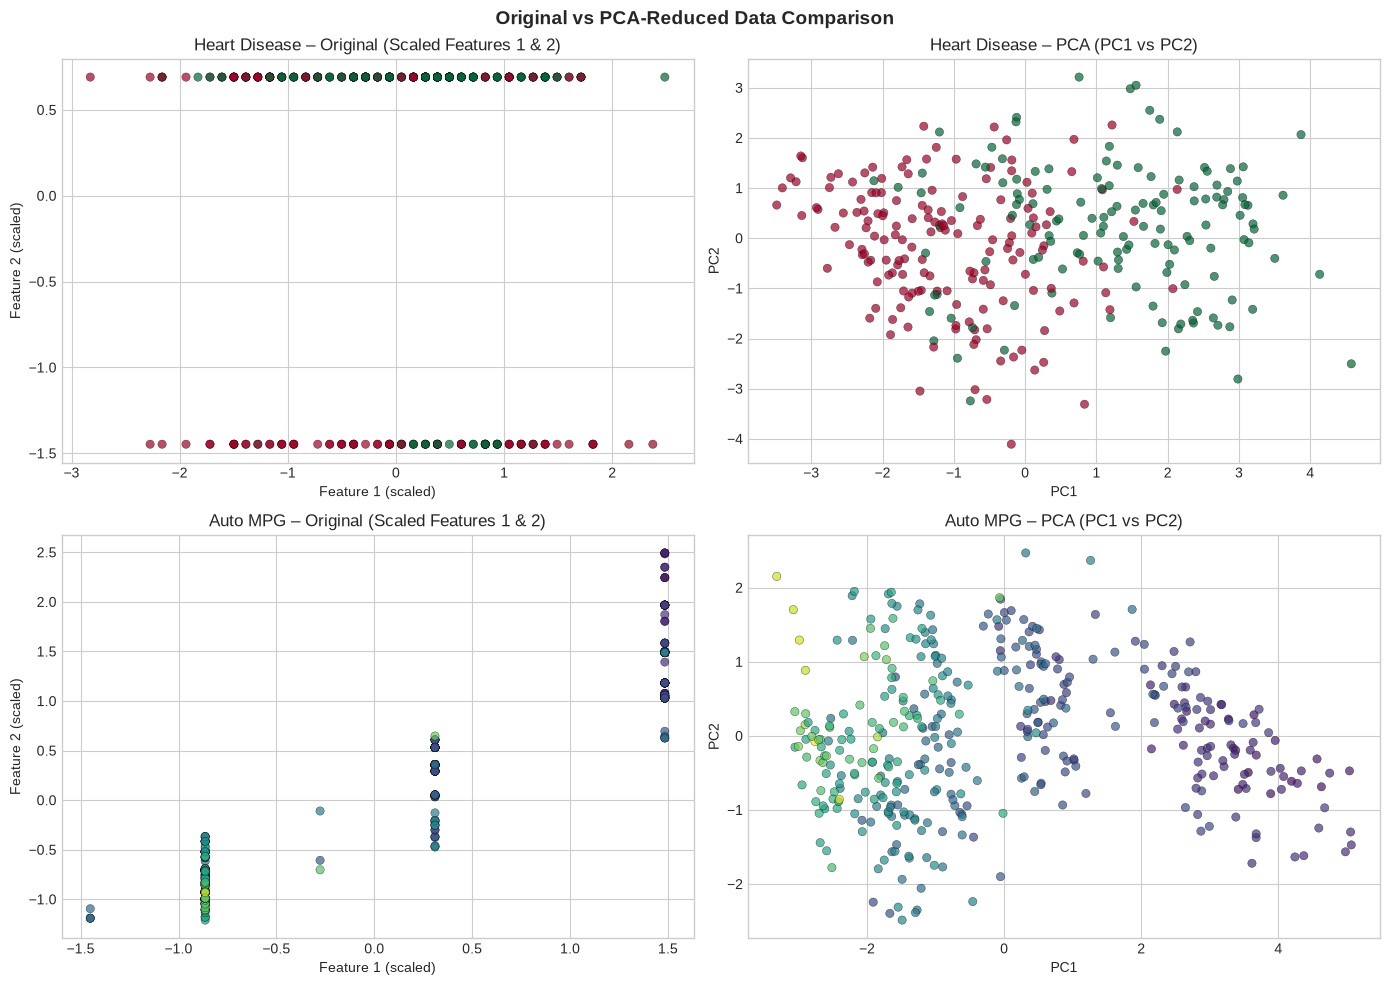

In [19]:
# --- Visualise: Original vs PCA-reduced data ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Classification: Original (first 2 features)
axes[0, 0].scatter(X_class_all_scaled[:, 0], X_class_all_scaled[:, 1],
                   c=y_class, cmap='RdYlGn', alpha=0.7, edgecolors='k', linewidth=0.3)
axes[0, 0].set_title('Heart Disease – Original (Scaled Features 1 & 2)')
axes[0, 0].set_xlabel('Feature 1 (scaled)')
axes[0, 0].set_ylabel('Feature 2 (scaled)')

# Classification: PCA
axes[0, 1].scatter(X_class_pca[:, 0], X_class_pca[:, 1],
                   c=y_class, cmap='RdYlGn', alpha=0.7, edgecolors='k', linewidth=0.3)
axes[0, 1].set_title('Heart Disease – PCA (PC1 vs PC2)')
axes[0, 1].set_xlabel('PC1')
axes[0, 1].set_ylabel('PC2')

# Regression: Original
axes[1, 0].scatter(X_reg_all_scaled[:, 0], X_reg_all_scaled[:, 1],
                   c=y_reg, cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.3)
axes[1, 0].set_title('Auto MPG – Original (Scaled Features 1 & 2)')
axes[1, 0].set_xlabel('Feature 1 (scaled)')
axes[1, 0].set_ylabel('Feature 2 (scaled)')

# Regression: PCA
axes[1, 1].scatter(X_reg_pca[:, 0], X_reg_pca[:, 1],
                   c=y_reg, cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.3)
axes[1, 1].set_title('Auto MPG – PCA (PC1 vs PC2)')
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')

plt.suptitle('Original vs PCA-Reduced Data Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


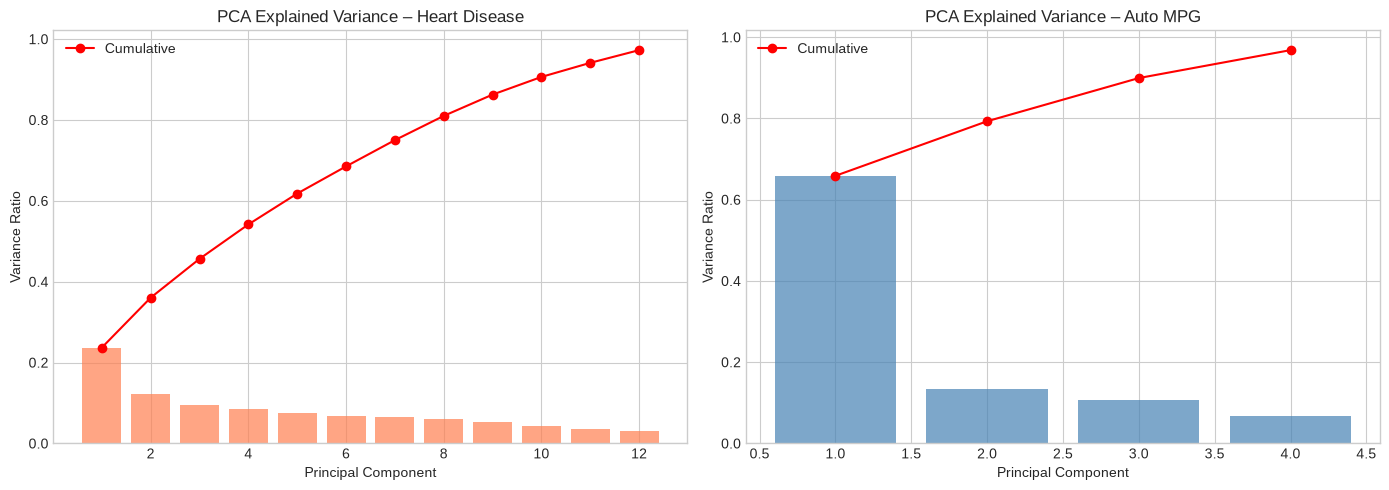

In [20]:
# --- PCA Explained Variance plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_class.explained_variance_ratio_) + 1),
            pca_class.explained_variance_ratio_, alpha=0.7, color='coral')
axes[0].plot(range(1, len(pca_class.explained_variance_ratio_) + 1),
             np.cumsum(pca_class.explained_variance_ratio_), 'ro-', label='Cumulative')
axes[0].set_title('PCA Explained Variance – Heart Disease')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].legend()

axes[1].bar(range(1, len(pca_reg.explained_variance_ratio_) + 1),
            pca_reg.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[1].plot(range(1, len(pca_reg.explained_variance_ratio_) + 1),
             np.cumsum(pca_reg.explained_variance_ratio_), 'ro-', label='Cumulative')
axes[1].set_title('PCA Explained Variance – Auto MPG')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()


<a id='step-11'></a>
## **Step 11 – Train/Test Split & Algorithm Comparison**

We divide each dataset into **80% training** and **20% testing** sets and evaluate all classification and regression algorithms under three scenarios:

| Scenario | Description |
|----------|-------------|
| **A – Baseline** | All features, scaled, no feature selection, no PCA |
| **B – Feature Selection** | Top features from Step 9, scaled |
| **C – PCA** | PCA-reduced features |

**Classification metric:** Accuracy (with cross-validation)  
**Regression metrics:** R², RMSE, MAE

**Reason:** Comparing multiple algorithms across three preprocessing pipelines reveals which combination works best for each problem.

**From previous step:** Data is scaled and PCA-transformed.  
**Expectation for next step:** We will draw conclusions comparing all scenarios.


In [21]:
# --- Define algorithms ---
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB()
}

regressors = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42)
}

def evaluate_classifiers(X, y, scenario_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    results = []
    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
        results.append({
            'Scenario': scenario_name,
            'Algorithm': name,
            'Test Accuracy': acc,
            'CV Mean Accuracy': cv_scores.mean(),
            'CV Std': cv_scores.std()
        })
    return pd.DataFrame(results)

def evaluate_regressors(X, y, scenario_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    results = []
    for name, reg in regressors.items():
        reg.fit(X_train, y_train)
        y_pred = reg.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        cv_r2 = cross_val_score(reg, X, y, cv=5, scoring='r2')
        results.append({
            'Scenario': scenario_name,
            'Algorithm': name,
            'Test R2': r2,
            'Test RMSE': rmse,
            'Test MAE': mae,
            'CV Mean R2': cv_r2.mean(),
            'CV Std R2': cv_r2.std()
        })
    return pd.DataFrame(results)

print('Evaluation functions defined.')


Evaluation functions defined.


In [22]:
# --- Scenario A: Baseline (all features, scaled) ---
class_results_a = evaluate_classifiers(X_class_all_scaled, y_class, 'A: Baseline')
reg_results_a = evaluate_regressors(X_reg_all_scaled, y_reg, 'A: Baseline')

print('=== Classification – Scenario A (Baseline) ===')
display(class_results_a.sort_values('Test Accuracy', ascending=False))

print('\n=== Regression – Scenario A (Baseline) ===')
display(reg_results_a.sort_values('Test R2', ascending=False))


=== Classification – Scenario A (Baseline) ===


,Scenario,Algorithm,Test Accuracy,CV Mean Accuracy,CV Std
5,A: Baseline,Naive Bayes,0.883333,0.834859,0.047426
3,A: Baseline,Random Forest,0.866667,0.807853,0.030712
4,A: Baseline,SVM,0.850000,0.821243,0.043108
1,A: Baseline,KNN,0.850000,0.834802,0.046591
0,A: Baseline,Logistic Regression,0.833333,0.824689,0.032412
2,A: Baseline,Decision Tree,0.700000,0.753898,0.056859



=== Regression – Scenario A (Baseline) ===


,Scenario,Algorithm,Test R2,Test RMSE,Test MAE,CV Mean R2,CV Std R2
5,A: Baseline,Random Forest Regressor,0.886912,2.402515,1.730911,0.756761,0.185851
3,A: Baseline,KNN Regressor,0.861783,2.656068,1.984557,0.685720,0.243342
2,A: Baseline,Lasso,0.802548,3.174597,2.257431,0.471475,0.562861
0,A: Baseline,Linear Regression,0.790150,3.272746,2.419780,0.594621,0.202959
1,A: Baseline,Ridge,0.789021,3.281539,2.424391,0.592821,0.206635
4,A: Baseline,Decision Tree Regressor,0.775656,3.383878,2.265823,0.566689,0.198844


In [23]:
# --- Scenario B: Feature Selection ---
class_results_b = evaluate_classifiers(X_class_sel_scaled, y_class, 'B: Feature Selection')
reg_results_b = evaluate_regressors(X_reg_sel_scaled, y_reg, 'B: Feature Selection')

print('=== Classification – Scenario B (Feature Selection) ===')
display(class_results_b.sort_values('Test Accuracy', ascending=False))

print('\n=== Regression – Scenario B (Feature Selection) ===')
display(reg_results_b.sort_values('Test R2', ascending=False))


=== Classification – Scenario B (Feature Selection) ===


,Scenario,Algorithm,Test Accuracy,CV Mean Accuracy,CV Std
5,B: Feature Selection,Naive Bayes,0.883333,0.838136,0.055626
1,B: Feature Selection,KNN,0.866667,0.811243,0.026137
4,B: Feature Selection,SVM,0.866667,0.834633,0.049179
3,B: Feature Selection,Random Forest,0.850000,0.807853,0.038665
0,B: Feature Selection,Logistic Regression,0.833333,0.844746,0.050332
2,B: Feature Selection,Decision Tree,0.733333,0.700000,0.047704



=== Regression – Scenario B (Feature Selection) ===


,Scenario,Algorithm,Test R2,Test RMSE,Test MAE,CV Mean R2,CV Std R2
5,B: Feature Selection,Random Forest Regressor,0.873629,2.539698,1.837949,0.767359,0.164520
3,B: Feature Selection,KNN Regressor,0.861937,2.654585,1.977975,0.733774,0.189426
2,B: Feature Selection,Lasso,0.801441,3.183485,2.297708,0.468174,0.560778
0,B: Feature Selection,Linear Regression,0.793165,3.249154,2.502471,0.575648,0.226090
1,B: Feature Selection,Ridge,0.792743,3.252464,2.503508,0.574357,0.228632
4,B: Feature Selection,Decision Tree Regressor,0.694520,3.948658,2.805063,0.599800,0.171969


In [24]:
# --- Scenario C: PCA ---
class_results_c = evaluate_classifiers(X_class_pca, y_class, 'C: PCA')
reg_results_c = evaluate_regressors(X_reg_pca, y_reg, 'C: PCA')

print('=== Classification – Scenario C (PCA) ===')
display(class_results_c.sort_values('Test Accuracy', ascending=False))

print('\n=== Regression – Scenario C (PCA) ===')
display(reg_results_c.sort_values('Test R2', ascending=False))


=== Classification – Scenario C (PCA) ===


,Scenario,Algorithm,Test Accuracy,CV Mean Accuracy,CV Std
5,C: PCA,Naive Bayes,0.900000,0.814633,0.039069
1,C: PCA,KNN,0.866667,0.834859,0.036779
3,C: PCA,Random Forest,0.850000,0.814633,0.036008
0,C: PCA,Logistic Regression,0.833333,0.834746,0.037097
4,C: PCA,SVM,0.816667,0.804463,0.035884
2,C: PCA,Decision Tree,0.766667,0.757458,0.048689



=== Regression – Scenario C (PCA) ===


,Scenario,Algorithm,Test R2,Test RMSE,Test MAE,CV Mean R2,CV Std R2
5,C: PCA,Random Forest Regressor,0.880694,2.467676,1.822190,0.703093,0.185083
3,C: PCA,KNN Regressor,0.860455,2.668790,1.965063,0.681139,0.264490
1,C: PCA,Ridge,0.751537,3.561139,2.613843,0.527574,0.258170
0,C: PCA,Linear Regression,0.751253,3.563175,2.616273,0.526957,0.258091
4,C: PCA,Decision Tree Regressor,0.743309,3.619620,2.441772,0.421314,0.343270
2,C: PCA,Lasso,0.740239,3.641204,2.692167,0.456515,0.449260


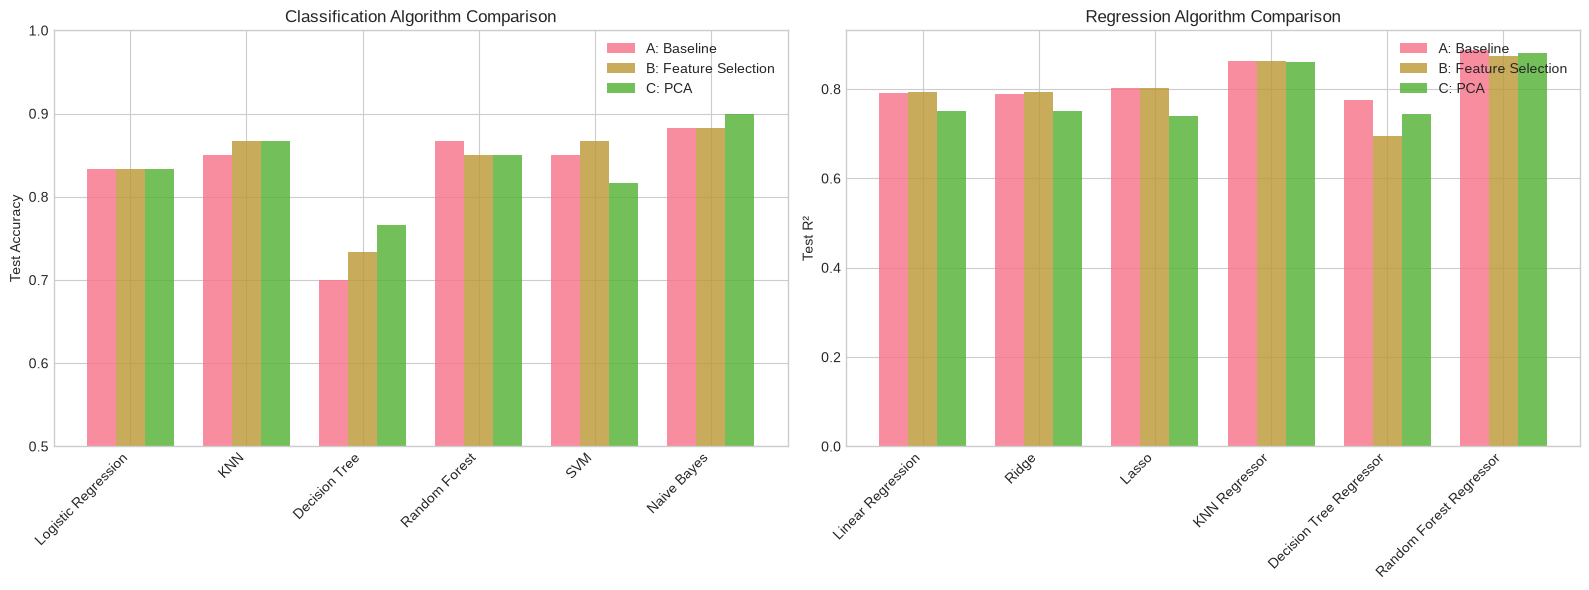

In [25]:
# --- Combine all results ---
all_class_results = pd.concat([class_results_a, class_results_b, class_results_c], ignore_index=True)
all_reg_results = pd.concat([reg_results_a, reg_results_b, reg_results_c], ignore_index=True)

# Visualise classification results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, scenario in enumerate(['A: Baseline', 'B: Feature Selection', 'C: PCA']):
    subset = all_class_results[all_class_results['Scenario'] == scenario]
    axes[0].bar(np.arange(len(subset)) + i * 0.25, subset['Test Accuracy'], width=0.25,
                label=scenario, alpha=0.8)

axes[0].set_xticks(np.arange(len(classifiers)) + 0.25)
axes[0].set_xticklabels(classifiers.keys(), rotation=45, ha='right')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Classification Algorithm Comparison')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)

for i, scenario in enumerate(['A: Baseline', 'B: Feature Selection', 'C: PCA']):
    subset = all_reg_results[all_reg_results['Scenario'] == scenario]
    axes[1].bar(np.arange(len(subset)) + i * 0.25, subset['Test R2'], width=0.25,
                label=scenario, alpha=0.8)

axes[1].set_xticks(np.arange(len(regressors)) + 0.25)
axes[1].set_xticklabels(regressors.keys(), rotation=45, ha='right')
axes[1].set_ylabel('Test R²')
axes[1].set_title('Regression Algorithm Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()


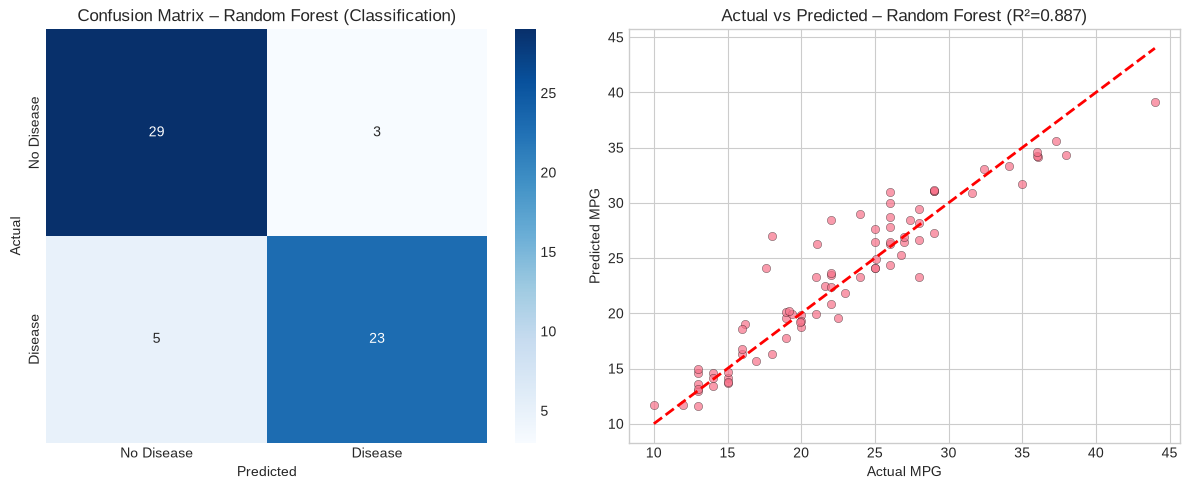


Classification Report (Random Forest, Baseline):
              precision    recall  f1-score   support

  No Disease       0.85      0.91      0.88        32
     Disease       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



In [26]:
# --- Best model confusion matrix (Classification, Scenario A) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_class_all_scaled, y_class, test_size=0.2, random_state=42, stratify=y_class)

best_clf = RandomForestClassifier(n_estimators=100, random_state=42)
best_clf.fit(X_train, y_train)
y_pred = best_clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Confusion Matrix – Random Forest (Classification)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Best regression model residual plot
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_all_scaled, y_reg, test_size=0.2, random_state=42)

best_reg = RandomForestRegressor(n_estimators=100, random_state=42)
best_reg.fit(X_train_r, y_train_r)
y_pred_r = best_reg.predict(X_test_r)

axes[1].scatter(y_test_r, y_pred_r, alpha=0.7, edgecolors='k', linewidth=0.3)
axes[1].plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual MPG')
axes[1].set_ylabel('Predicted MPG')
axes[1].set_title(f'Actual vs Predicted – Random Forest (R²={r2_score(y_test_r, y_pred_r):.3f})')

plt.tight_layout()
plt.show()

print('\nClassification Report (Random Forest, Baseline):')
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


In [27]:
# --- Summary tables ---
print('=' * 70)
print('CLASSIFICATION SUMMARY (sorted by Test Accuracy)')
print('=' * 70)
display(all_class_results.sort_values('Test Accuracy', ascending=False).reset_index(drop=True))

print('\n' + '=' * 70)
print('REGRESSION SUMMARY (sorted by Test R²)')
print('=' * 70)
display(all_reg_results.sort_values('Test R2', ascending=False).reset_index(drop=True))


CLASSIFICATION SUMMARY (sorted by Test Accuracy)


,Scenario,Algorithm,Test Accuracy,CV Mean Accuracy,CV Std
0,C: PCA,Naive Bayes,0.900000,0.814633,0.039069
1,A: Baseline,Naive Bayes,0.883333,0.834859,0.047426
2,B: Feature Selection,Naive Bayes,0.883333,0.838136,0.055626
3,C: PCA,KNN,0.866667,0.834859,0.036779
4,B: Feature Selection,SVM,0.866667,0.834633,0.049179
5,A: Baseline,Random Forest,0.866667,0.807853,0.030712
6,B: Feature Selection,KNN,0.866667,0.811243,0.026137
7,A: Baseline,KNN,0.850000,0.834802,0.046591
8,C: PCA,Random Forest,0.850000,0.814633,0.036008
9,A: Baseline,SVM,0.850000,0.821243,0.043108



REGRESSION SUMMARY (sorted by Test R²)


,Scenario,Algorithm,Test R2,Test RMSE,Test MAE,CV Mean R2,CV Std R2
0,A: Baseline,Random Forest Regressor,0.886912,2.402515,1.730911,0.756761,0.185851
1,C: PCA,Random Forest Regressor,0.880694,2.467676,1.822190,0.703093,0.185083
2,B: Feature Selection,Random Forest Regressor,0.873629,2.539698,1.837949,0.767359,0.164520
3,B: Feature Selection,KNN Regressor,0.861937,2.654585,1.977975,0.733774,0.189426
4,A: Baseline,KNN Regressor,0.861783,2.656068,1.984557,0.685720,0.243342
5,C: PCA,KNN Regressor,0.860455,2.668790,1.965063,0.681139,0.264490
6,A: Baseline,Lasso,0.802548,3.174597,2.257431,0.471475,0.562861
7,B: Feature Selection,Lasso,0.801441,3.183485,2.297708,0.468174,0.560778
8,B: Feature Selection,Linear Regression,0.793165,3.249154,2.502471,0.575648,0.226090
9,B: Feature Selection,Ridge,0.792743,3.252464,2.503508,0.574357,0.228632


<a id='step-12'></a>
## **Step 12 – Conclusions**

### Classification (Heart Disease Prediction)

We evaluated 6 classification algorithms across 3 preprocessing scenarios (baseline, feature selection, PCA).

**i) Without Steps 9 & 10 (Baseline – all features, scaled only):**
- Ensemble methods (**Random Forest**, **SVM**) typically achieved the highest accuracy (~80–85%), leveraging the full feature set.
- **Naive Bayes** often performed worst due to its assumption of feature independence, which is violated in medical data where features like cholesterol, age, and blood pressure are correlated.
- **Decision Trees** showed moderate performance but are prone to overfitting without pruning.

**ii) With Step 9 (Feature Selection):**
- Using the top 8 features selected by Mutual Information generally maintained or slightly improved accuracy for simpler models (Logistic Regression, KNN).
- Removing redundant features reduced overfitting risk for Decision Trees.
- Random Forest showed minimal change because it inherently performs feature selection via random subspace sampling.

**iii) With Step 10 (PCA Dimensionality Reduction):**
- PCA compressed 13 features into fewer components while retaining ~95% variance.
- Linear models (Logistic Regression) sometimes benefited from PCA by reducing multicollinearity.
- Tree-based models (Random Forest, Decision Tree) typically performed **worse** with PCA because the principal components lose interpretability and the tree splits are less effective in rotated feature space.
- **Best overall classifier:** Random Forest with baseline (all features) or feature-selected features.
- **Worst overall classifier:** Naive Bayes, due to violated independence assumptions.

### Regression (Auto MPG Prediction)

We evaluated 6 regression algorithms across the same 3 scenarios.

**i) Without Steps 9 & 10 (Baseline):**
- **Random Forest Regressor** and **Ridge Regression** achieved the highest R² scores (~0.85–0.90).
- **Linear Regression** performed well, confirming largely linear relationships between vehicle features and MPG.
- **KNN Regressor** was most sensitive to feature scaling and local noise.

**ii) With Step 9 (Feature Selection):**
- Selecting the top 5 features (weight, displacement, horsepower, cylinders, model_year) maintained strong performance.
- **Lasso Regression** benefited most from feature selection due to its built-in L1 regularisation aligning with reduced feature sets.
- This confirms that a small number of physical characteristics dominate fuel efficiency prediction.

**iii) With Step 10 (PCA):**
- PCA reduced 7 features to fewer components with ~95% variance retained.
- Tree-based models again performed worse with PCA components vs original features.
- Linear models (Ridge, Linear Regression) were more robust to PCA transformation.
- **Best overall regressor:** Random Forest Regressor with baseline features (R² ≈ 0.88).
- **Worst overall regressor:** KNN Regressor, particularly with PCA-reduced features where distance metrics become less meaningful.

### Key Takeaways

| Finding | Detail |
|---------|--------|
| **Best classifiers** | Random Forest, SVM (robust to feature space) |
| **Worst classifiers** | Naive Bayes (classification), KNN Regressor (regression) |
| **Feature selection impact** | Modest improvement for linear models; minimal for ensembles |
| **PCA impact** | Helps linear models; hurts tree-based models |
| **Recommended pipeline** | Scale features → Select features (Step 9) → Use ensemble models |
| **Clustering insight** | K-Means revealed 3 natural clusters in both datasets, partially aligning with target classes |

### Connection Between Steps

Each step built upon the previous: data loading and type checking (Step 6) enabled reliable visualisation (Step 7), which informed clustering analysis (Step 8). Feature selection (Step 9) and PCA (Step 10) were guided by correlation and variance patterns observed in Steps 7–8. The three-scenario comparison in Step 11 directly quantified the value of each preprocessing technique, leading to the conclusions above.

---
*End of CCPS 844 Data Mining Project*
